In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [29]:
data = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/clean_data.csv')
#unfortunately our genre encoding too heavily effects the data and must be removed along with our Unnamed:0 column
data = data.drop(columns=['Unnamed: 0','genre_blues', 'genre_country','genre_hip hop', 'genre_jazz', 'genre_pop', 'genre_reggae','genre_rock'])
data.columns

Index(['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age'],
      dtype='object')

In [18]:
X1 = data.loc[:, ['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age']].values

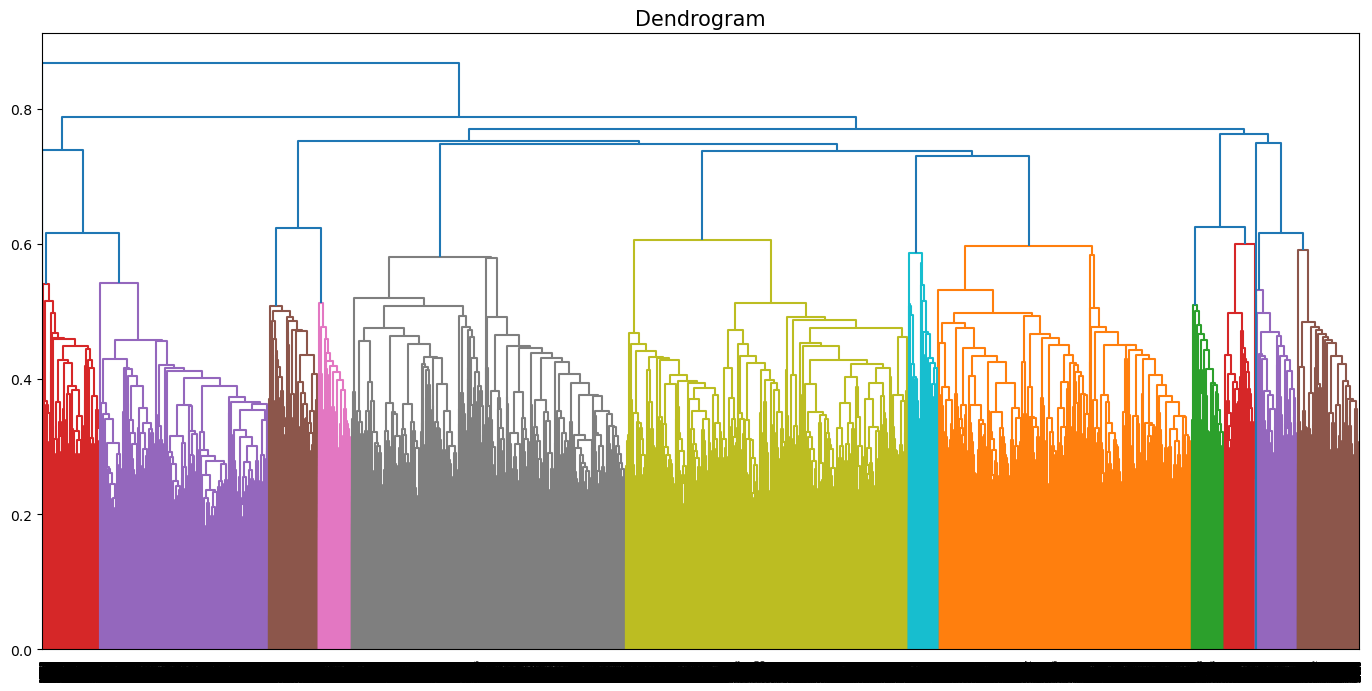

In [19]:
plt.figure(figsize = (17, 8))

# TODO: create dendogram using the "average" linkage method
# DOCUMENTATION: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
dendo = dendrogram(linkage(X1, method = 'average'))
plt.title('Dendrogram', fontsize = 15)
plt.xticks()
plt.show()

In [20]:
plt.figure(figsize = (17, 8))

# TODO: create dendogram using the "single" linkage method
# DOCUMENTATION: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
dendo2 = dendrogram(linkage(X1, method = 'single'))
plt.title('Dendrogram', fontsize = 15)
plt.show()

RecursionError: maximum recursion depth exceeded

<Figure size 1700x800 with 0 Axes>

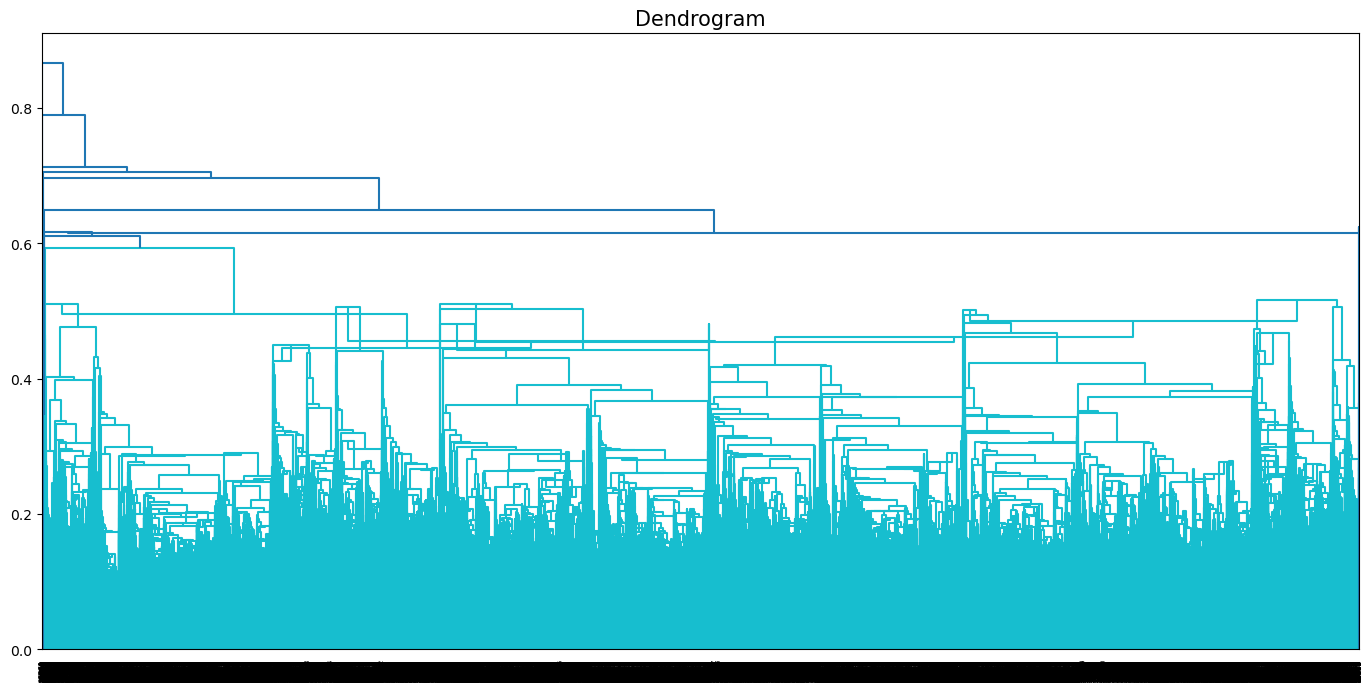

In [21]:
plt.figure(figsize = (17, 8))

# TODO: create dendogram using the "centroid" linkage method
# DOCUMENTATION: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
dendo3 = dendrogram(linkage(X1, method = 'centroid'))
plt.title('Dendrogram', fontsize = 15)
plt.show()

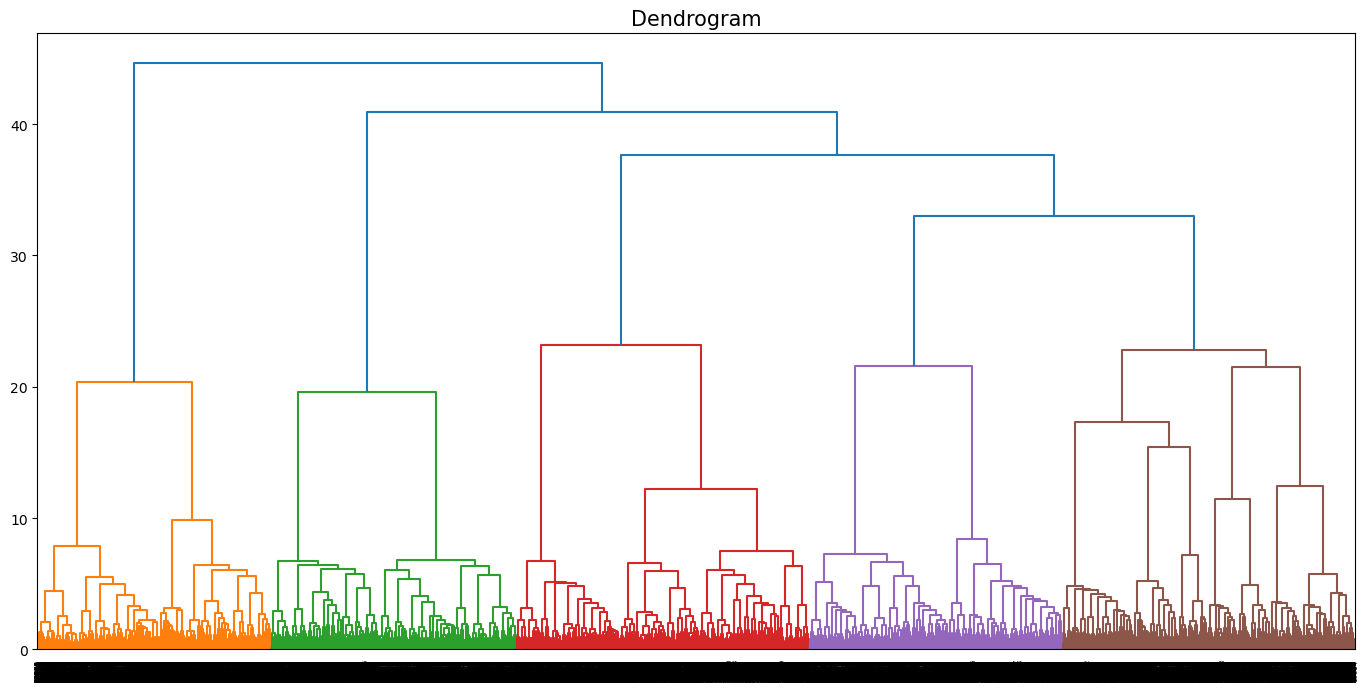

In [22]:
plt.figure(figsize = (17, 8))

# TODO: create dendogram using the "ward" linkage method
# DOCUMENTATION: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
dendo = dendrogram(linkage(X1, method = 'ward'))
plt.title('Dendrogram', fontsize = 15)
plt.show()

In [30]:
agc = AgglomerativeClustering(n_clusters = 7, metric = 'euclidean', linkage = 'ward')
# TODO: fit and predict your labels using your `X1` dataset

ward_labels = agc.fit_predict(X1)
data['labels'] = ward_labels
ward_clusters = data.groupby('labels')
ward_clusters.value_counts()

labels  dating    violence  world/life  night/time  shake the audience  family/gospel  romantic  communication  obscene   music     movement/places  light/visual perceptions  family/spiritual  sadness   feelings  age     
0       0.008772  0.008772  0.470259    0.008772    0.008772            0.008772       0.008772  0.008772       0.008772  0.380618  0.008772         0.008772                  0.008772          0.008772  0.008772  0.557143    2
        0.026316  0.026316  0.526316    0.026316    0.026316            0.026316       0.026316  0.026316       0.026316  0.026316  0.026316         0.026316                  0.026316          0.026316  0.026316  0.285714    2
        0.000337  0.011797  0.389925    0.000337    0.027736            0.025428       0.010490  0.000337       0.000337  0.027608  0.000337         0.315215                  0.012437          0.056866  0.082710  0.128571    1
        0.000344  0.035867  0.452044    0.000344    0.029401            0.000344       0.000344  

In [24]:
agc = AgglomerativeClustering(n_clusters = 7, metric = 'euclidean', linkage = 'average')
# TODO: fit and predict your labels using your `X1` dataset

ward_labels = agc.fit_predict(X1)
data['labels'] = ward_labels
ward_clusters = data.groupby('labels')
ward_clusters

,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,...,feelings,age,genre_blues,genre_country,genre_hip hop,genre_jazz,genre_pop,genre_reggae,genre_rock,labels
0,0.000598,0.063746,0.000598,0.000598,0.000598,0.048857,0.017104,0.263751,0.000598,0.039288,...,0.117175,1.000000,0,0,0,0,1,0,0,4
1,0.035537,0.096777,0.443435,0.001284,0.001284,0.027007,0.001284,0.001284,0.001284,0.118034,...,0.001284,1.000000,0,0,0,0,1,0,0,0
2,0.002770,0.002770,0.002770,0.002770,0.002770,0.002770,0.158564,0.250668,0.002770,0.323794,...,0.225422,1.000000,0,0,0,0,1,0,0,6
3,0.048249,0.001548,0.001548,0.001548,0.021500,0.001548,0.411536,0.001548,0.001548,0.001548,...,0.001548,1.000000,0,0,0,0,1,0,0,4
4,0.001350,0.001350,0.417772,0.001350,0.001350,0.001350,0.463430,0.001350,0.001350,0.001350,...,0.001350,1.000000,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28357,0.001350,0.001350,0.001350,0.001350,0.001350,0.001350,0.001350,0.001350,0.391651,0.001350,...,0.001350,0.014286,0,0,1,0,0,0,0,3
28358,0.001284,0.001284,0.035338,0.001284,0.001284,0.001284,0.066324,0.203889,0.318910,0.058152,...,0.001284,0.014286,0,0,1,0,0,0,0,3
28359,0.001504,0.154302,0.168988,0.001504,0.039755,0.001504,0.035401,0.001504,0.356685,0.001504,...,0.001504,0.014286,0,0,1,0,0,0,0,3
28360,0.001196,0.001196,0.001196,0.001196,0.048359,0.001196,0.001196,0.001196,0.492434,0.103614,...,0.001196,0.014286,0,0,1,0,0,0,0,3
